In [86]:
from torchvision import datasets
from torchvision import transforms
import torch
import numpy as np
import torch.nn as nn
import matplotlib.pyplot as plt
import random

tensor_transform = transforms.ToTensor()

dataset = datasets.MNIST(root = "./data",
                         train = True,
                         transform = tensor_transform,
                         download = True)

loader = torch.utils.data.DataLoader(dataset = dataset,
                                     batch_size = 32,
                                     shuffle = True)


In [88]:


print(torch.cuda.device_count() )             # число доступных GPU

cpu = torch.device("cpu")
gpu = torch.device("cuda:0" if torch.cuda.is_available() else "cpu")

random.seed(2024)

0


In [90]:
# 28*28 ==> 9 ==> 28*28


class AE(torch.nn.Module):
    def __init__(self):
        super().__init__()
        self.encoder = nn.Sequential(
            torch.nn.Linear(28*28, 128),
            torch.nn.ReLU(),
            torch.nn.Linear(128, 64),
            torch.nn.ReLU(),
            torch.nn.Linear(64, 36),
            torch.nn.ReLU(),
            torch.nn.Linear(36, 18),
            torch.nn.ReLU(),
            torch.nn.Linear(18, 9)
        )

        self.classifier = nn.Sequential(
            nn.Linear(9, 32),
            nn.ReLU(),
            nn.Linear(32, 10)  # 10 классов для MNIST
        )

    def forward(self, x):
        encoded = self.encoder(x)
        logits = self.classifier(encoded)
        return logits

In [92]:

model = AE().to(gpu)

loss_function = torch.nn.CrossEntropyLoss()

optimizer = torch.optim.SGD(model.parameters(),
                             lr = 1e-1,
                             weight_decay = 1e-8)

for param in model.encoder.parameters():
    param.requires_grad = False

In [96]:

epochs = 50

outputs = []
losses = []
labels = []

for epoch in range(20):  
    model.train()
    epoch_loss = 0
    correct_total = 0  
    total_samples = 0  

    for images, labels in loader:
        images = images.view(-1, 28 * 28).to(gpu)
        labels = labels.to(gpu)

        optimizer.zero_grad()
        outputs = model(images)  
        
        loss = loss_function(outputs, labels)
        loss.backward()
        optimizer.step()
        
        epoch_loss += loss.item()
        losses.append(loss.item())

        predicted_labels = torch.argmax(outputs, dim=1)
        correct_total += (predicted_labels == labels).sum().item()
        total_samples += labels.size(0)

    epoch_accuracy = correct_total / total_samples
    print(f"Epoch {epoch+1}, Loss: {epoch_loss / len(loader):.4f}, Accuracy: {epoch_accuracy:.4f}")


Epoch 1, Loss: 2.3026, Accuracy: 0.1100
Epoch 2, Loss: 2.3021, Accuracy: 0.1103
Epoch 3, Loss: 2.3017, Accuracy: 0.1111
Epoch 4, Loss: 2.3013, Accuracy: 0.1127
Epoch 5, Loss: 2.3009, Accuracy: 0.1124
Epoch 6, Loss: 2.3003, Accuracy: 0.1148
Epoch 7, Loss: 2.2997, Accuracy: 0.1155
Epoch 8, Loss: 2.2986, Accuracy: 0.1175
Epoch 9, Loss: 2.2973, Accuracy: 0.1198
Epoch 10, Loss: 2.2958, Accuracy: 0.1242
Epoch 11, Loss: 2.2934, Accuracy: 0.1282
Epoch 12, Loss: 2.2902, Accuracy: 0.1323
Epoch 13, Loss: 2.2862, Accuracy: 0.1387
Epoch 14, Loss: 2.2813, Accuracy: 0.1419
Epoch 15, Loss: 2.2750, Accuracy: 0.1449
Epoch 16, Loss: 2.2677, Accuracy: 0.1500
Epoch 17, Loss: 2.2587, Accuracy: 0.1525
Epoch 18, Loss: 2.2506, Accuracy: 0.1573
Epoch 19, Loss: 2.2429, Accuracy: 0.1590
Epoch 20, Loss: 2.2349, Accuracy: 0.1639


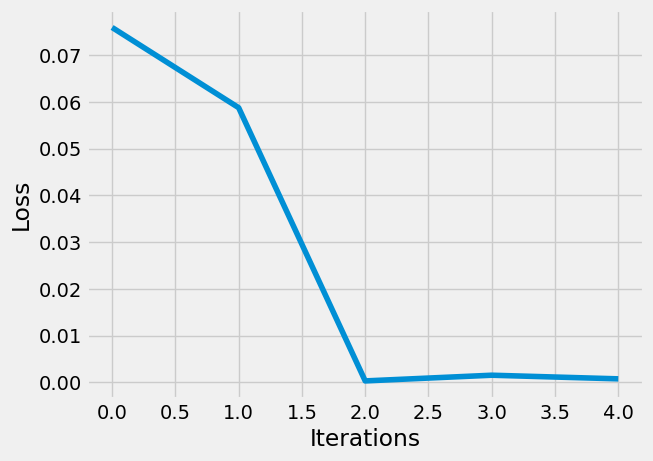

In [37]:

loss_values = losses[-min(5, len(losses)):]  # Последние 100 значений
plt.style.use('fivethirtyeight')
plt.xlabel('Iterations')
plt.ylabel('Loss')
plt.plot(loss_values)
plt.show()


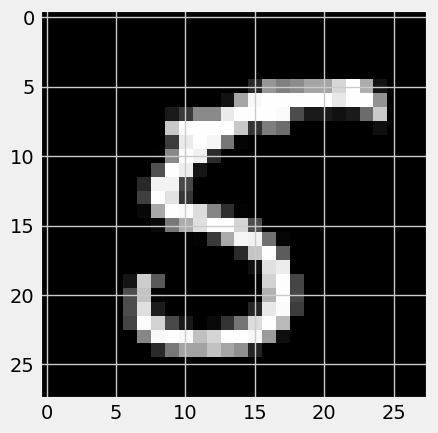

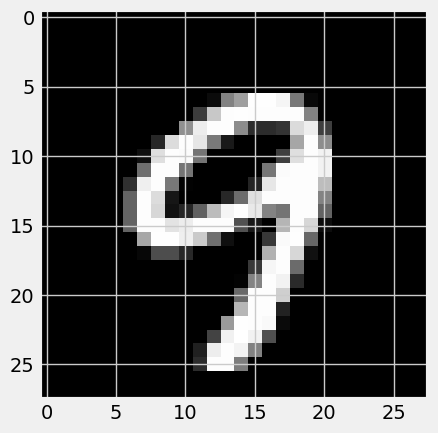

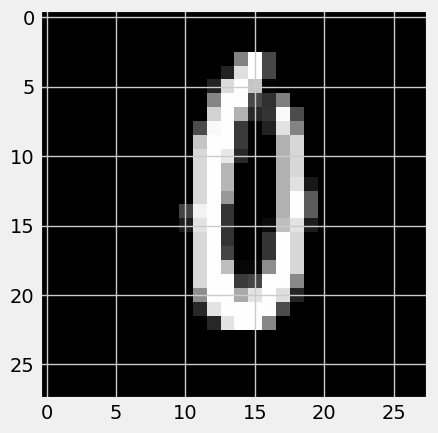

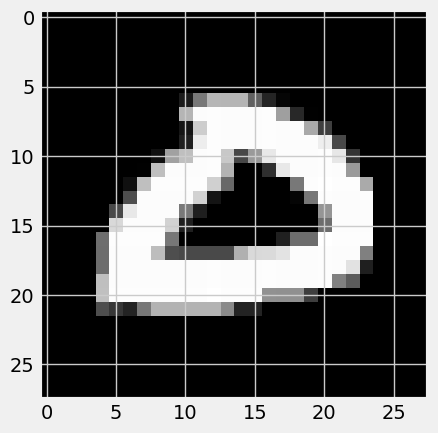

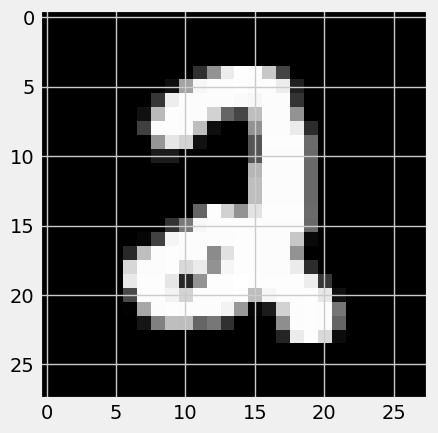

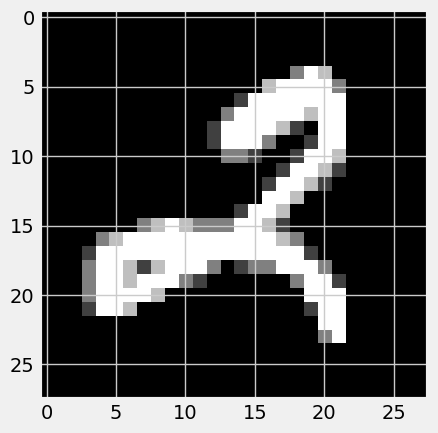

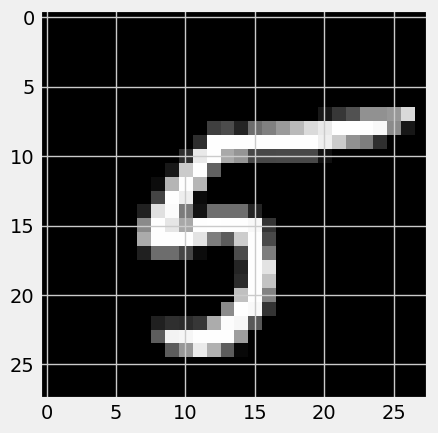

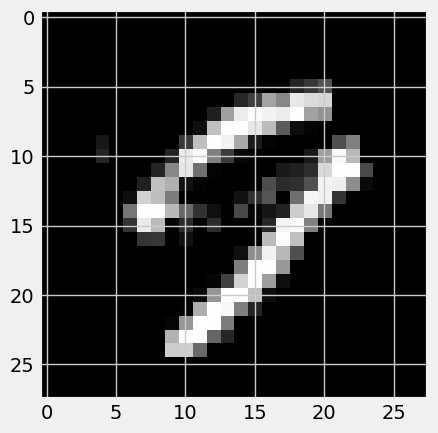

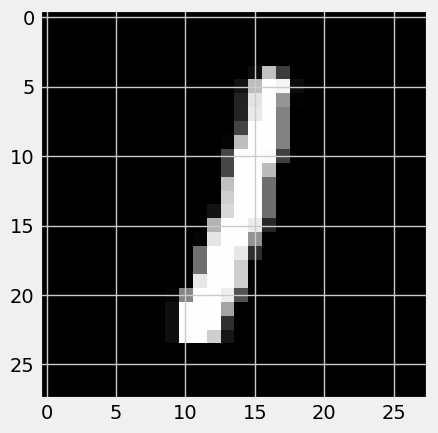

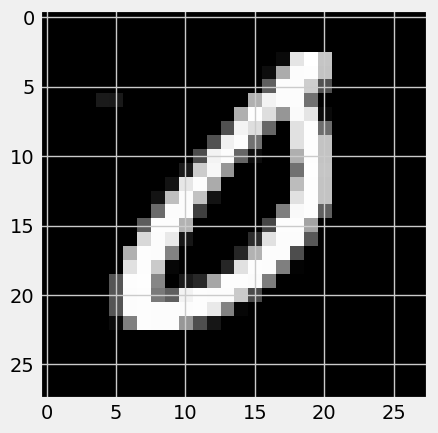

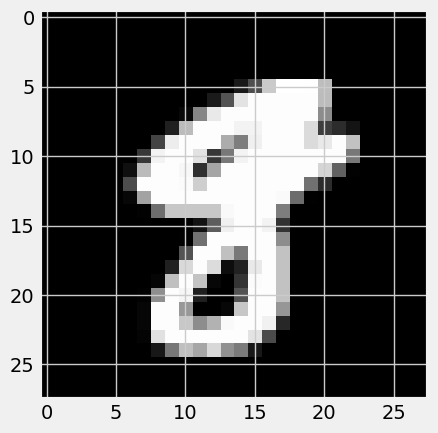

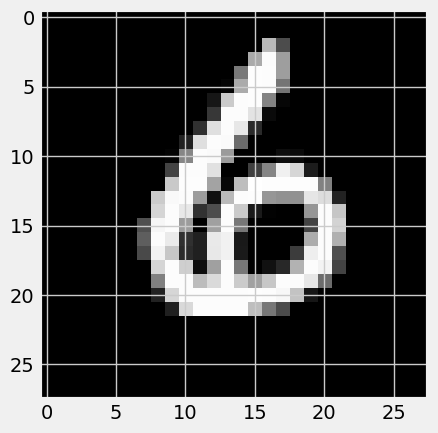

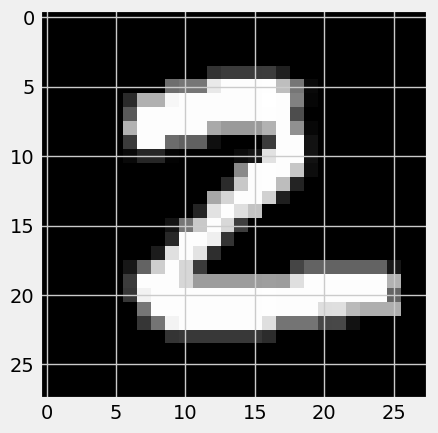

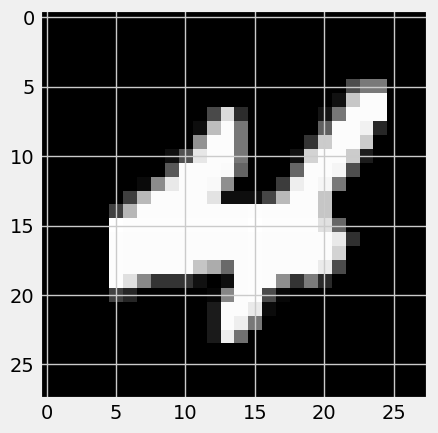

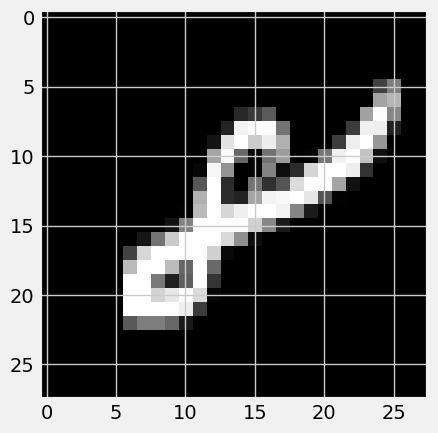

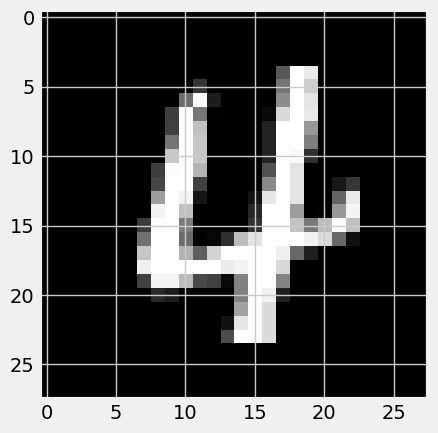

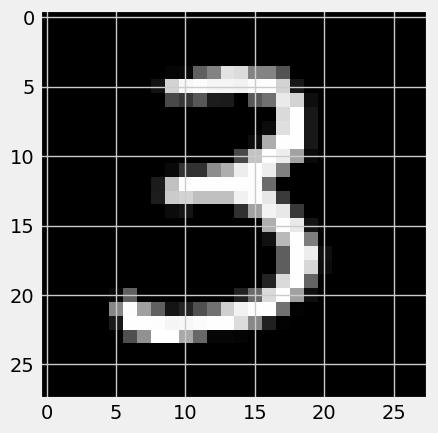

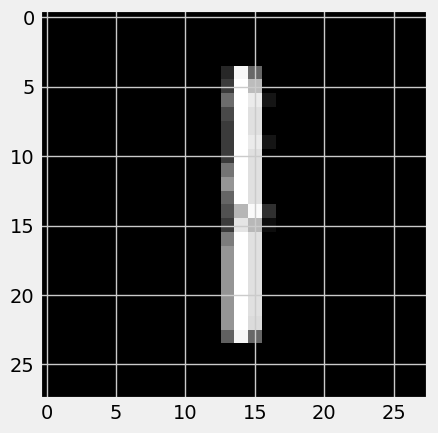

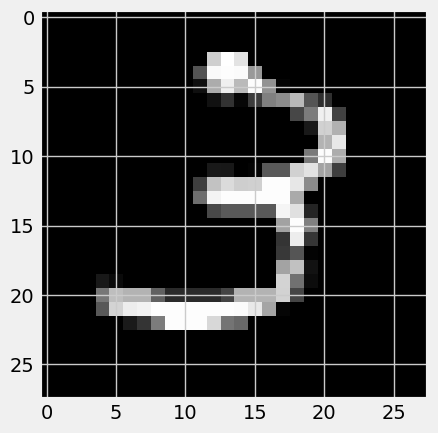

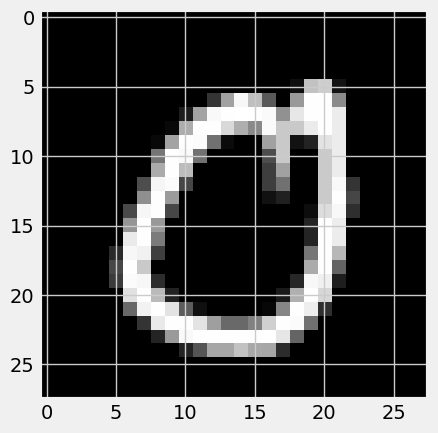

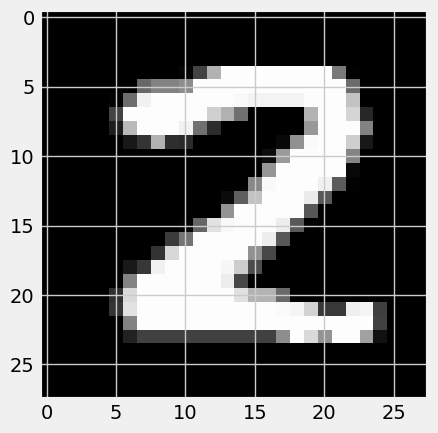

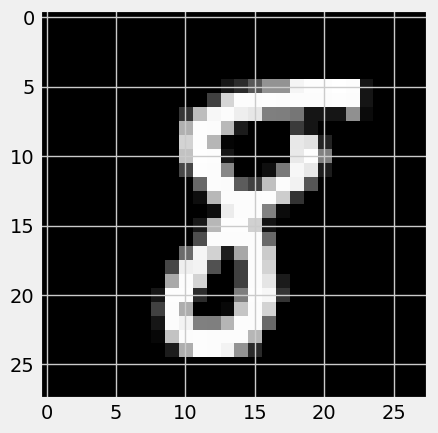

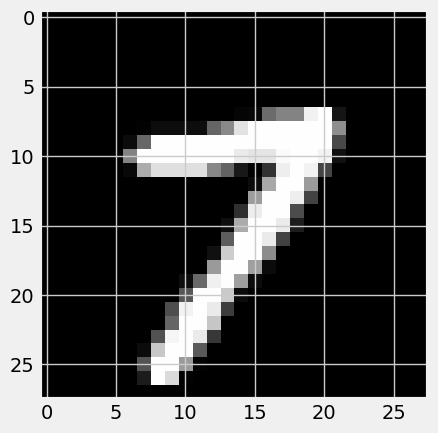

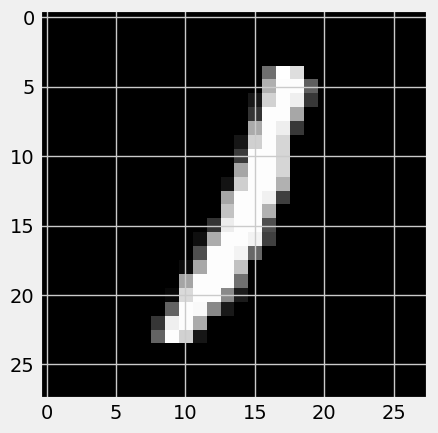

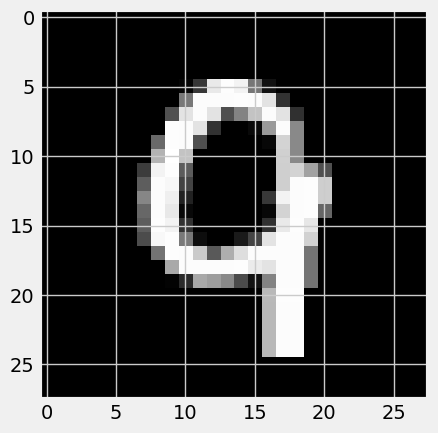

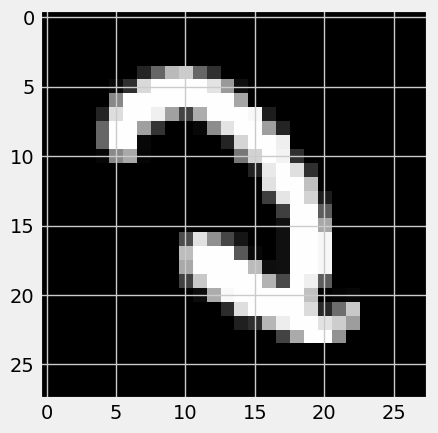

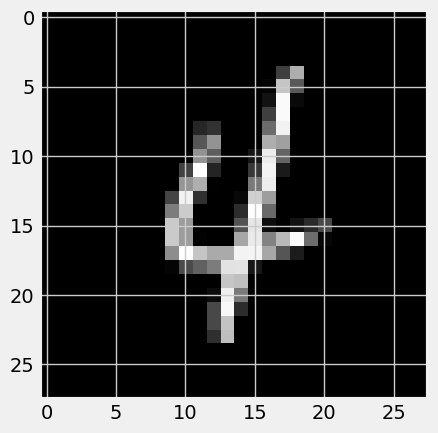

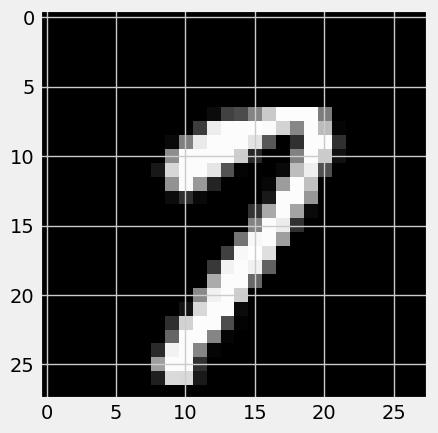

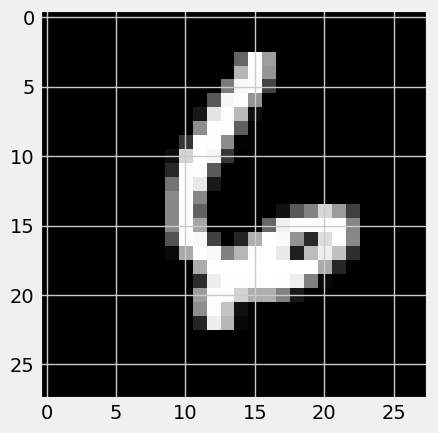

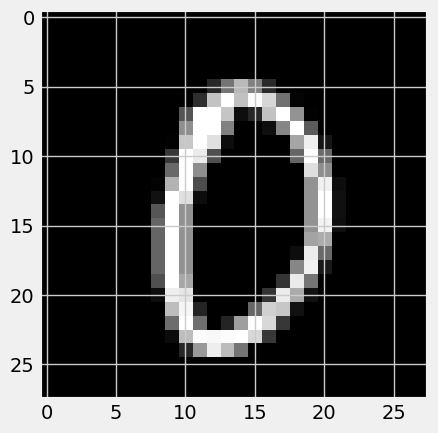

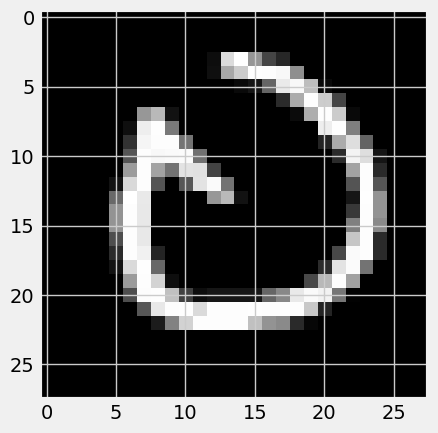

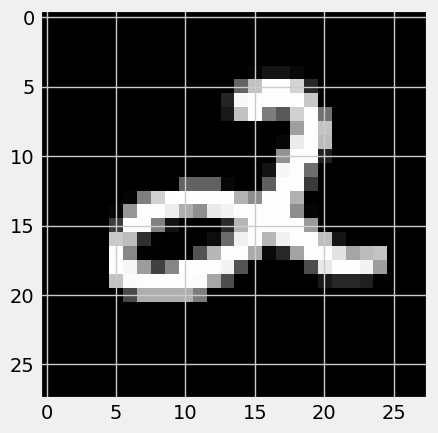

In [38]:
for i, item in enumerate(images):
    item = item.view(28, 28)  # Убираем -1, т.к. один элемент уже скалярный
    plt.imshow(item.cpu().detach().numpy(), cmap="gray")
    plt.show()

In [39]:
outputs.shape

torch.Size([32, 10])

In [40]:
images.shape

torch.Size([32, 784])

In [41]:
predicted_labels = torch.argmax(outputs, dim=1)  # Предсказанный класс
print(predicted_labels)

tensor([5, 9, 0, 0, 2, 2, 5, 9, 1, 0, 8, 6, 2, 4, 8, 4, 3, 1, 3, 0, 2, 8, 7, 1,
        9, 2, 4, 7, 6, 0, 0, 2])


In [70]:

# Detach and move to CPU, then convert to NumPy arrays
true_labels_np = labels.detach().cpu().numpy()
predicted_labels_np = predicted_labels.detach().cpu().numpy()

# Now print the classification report using scikit-learn
from sklearn.metrics import classification_report
print(classification_report(true_labels_np, predicted_labels_np))

              precision    recall  f1-score   support

           0       1.00      1.00      1.00         6
           1       1.00      1.00      1.00         3
           2       1.00      1.00      1.00         6
           3       1.00      1.00      1.00         2
           4       1.00      1.00      1.00         3
           5       1.00      1.00      1.00         2
           6       1.00      1.00      1.00         2
           7       1.00      1.00      1.00         2
           8       1.00      1.00      1.00         3
           9       1.00      1.00      1.00         3

    accuracy                           1.00        32
   macro avg       1.00      1.00      1.00        32
weighted avg       1.00      1.00      1.00        32

